# Decision Tree Classifier — Predicting Customer Churn

Every model in the previous series was Logistic Regression — a *linear* model, meaning
it can only draw a straight decision boundary between churners and non-churners. A
**Decision Tree** works completely differently: it splits the data repeatedly on
whatever feature best separates the classes at each step, building a branching set of
if/else rules. This can capture patterns a linear model fundamentally cannot — for
example, "customers over 50 in Germany with only 1 product" being high-risk, even if
none of those factors alone is a strong linear predictor.

## 1. Import Libraries

New addition: `GridSearchCV` — rather than picking hyperparameters by hand, this
systematically tries every combination from a defined grid and keeps whichever performs
best on cross-validation. `warnings.filterwarnings('ignore')` just suppresses harmless
sklearn version warnings so the output stays readable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              classification_report, f1_score, ConfusionMatrixDisplay,
                              confusion_matrix, roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [2]:
df1 = pd.read_csv('03_BankCustomer_OutlierChecked.csv')
df1.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39.0,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0


## 3. Define Features and Target

In [3]:
X = df1.drop(columns=['CustomerId', 'Surname', 'Exited'])
y = df1['Exited']

## 4. Train/Test Split

Same 70/30 stratified split used throughout the project, so results stay comparable to
every Logistic Regression variant.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## 5. Preprocessing

Same setup as before. Note: unlike Logistic Regression, Decision Trees don't actually
*need* feature scaling — they split on raw thresholds, not distances. `StandardScaler`
is kept here anyway for consistency with the rest of the project and because it does no
harm, but it's worth knowing it's not doing any real work for this particular model.

In [5]:
num_features = ["CreditScore", "Age", "EstimatedSalary", "Balance", "NumOfProducts", "Tenure"]
cat_features = ["Geography", "Gender", "HasCrCard", "IsActiveMember"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features)
    ]
)

## 6. Build the Pipeline

In [6]:
steps = [("preprocess", preprocessor),
         ("decision_tree", DecisionTreeClassifier(random_state=42))]

pipe = Pipeline(steps)
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('decision_tree', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3

## 7. Baseline: Untuned Decision Tree *(added)*

Before jumping to hyperparameter tuning, it's worth checking how a Decision Tree
performs with default settings — and, notably, with no imbalance-handling at all. This
tells us whether tree-based models are naturally more resistant to imbalance than
Logistic Regression was.

In [7]:
pipe.fit(X_train, y_train)
y_pred_baseline = pipe.predict(X_test)

print(f"Baseline Decision Tree — Accuracy: {accuracy_score(y_test, y_pred_baseline):.2f}, "
      f"Recall: {recall_score(y_test, y_pred_baseline):.2f}, "
      f"Precision: {precision_score(y_test, y_pred_baseline):.2f}, "
      f"F1: {f1_score(y_test, y_pred_baseline):.2f}")

Baseline Decision Tree — Accuracy: 0.79, Recall: 0.50, Precision: 0.49, F1: 0.50


Notice this untuned tree already reaches meaningfully higher recall than the untuned
Logistic Regression baseline did (0.19) — without any resampling or class weighting at
all. Decision Trees naturally handle some imbalance better because each split only
cares about improving purity locally, not fitting one global linear boundary. Still,
there's clear room for improvement, which is where tuning comes in.

## 8. Hyperparameter Grid

- `criterion` — the rule used to decide the best split at each node (`gini` impurity vs
  `entropy`/information gain — usually very similar in practice).
- `max_depth` — how many levels deep the tree can grow. Deeper trees fit training data
  more closely but risk overfitting; `None` means no limit.
- `min_samples_split` / `min_samples_leaf` — minimum data required to create or keep a
  split. Higher values prevent the tree from creating overly specific rules based on
  just a handful of data points.
- **`class_weight`** *(added to the grid)* — the reference version of this notebook
  didn't include this at all, meaning it never tested whether directly addressing the
  churn imbalance (the entire focus of the previous five notebooks) would help here too.
  Adding `None` vs `'balanced'` as a tunable option lets the grid search decide this
  automatically, rather than assuming a plain tree is unaffected by the imbalance.

In [8]:
param_grid = {
    'decision_tree__criterion': ['gini', 'entropy'],
    'decision_tree__max_depth': [None, 10, 20, 30],
    'decision_tree__min_samples_split': [2, 5, 10],
    'decision_tree__min_samples_leaf': [1, 2, 4],
    'decision_tree__class_weight': [None, 'balanced']
}

## 9. Run Grid Search

`cv=5` means each combination is evaluated using 5-fold cross-validation (the training
data is split 5 ways, and each combination is tested 5 times on different held-out
folds, then averaged) — this gives a more reliable estimate than a single train/test
split alone. `scoring='recall'` tells the search to pick whichever combination
maximizes recall on the churn class specifically, since that's the metric this whole
project has identified as the one that matters most for this business problem.

In [9]:
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'decision_tree__class_weight': [None, 'balanced'], 'decision_tree__criterion': ['gini', 'entropy'], 'decision_tree__max_depth': [None, 10, ...], 'decision_tree__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-vali

## 10. Best Parameters Found

In [10]:
grid_search.best_params_

{'decision_tree__class_weight': 'balanced',
 'decision_tree__criterion': 'entropy',
 'decision_tree__max_depth': 10,
 'decision_tree__min_samples_leaf': 4,
 'decision_tree__min_samples_split': 2}

## 11. Predict Using the Best Model

In [11]:
best_dt = grid_search.best_estimator_
y_pred = best_dt.predict(X_test)
y_pred

array([0, 0, 1, ..., 1, 1, 0], shape=(3000,))

## 12. Confusion Matrix

In [12]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[1865,  524],
       [ 174,  437]])

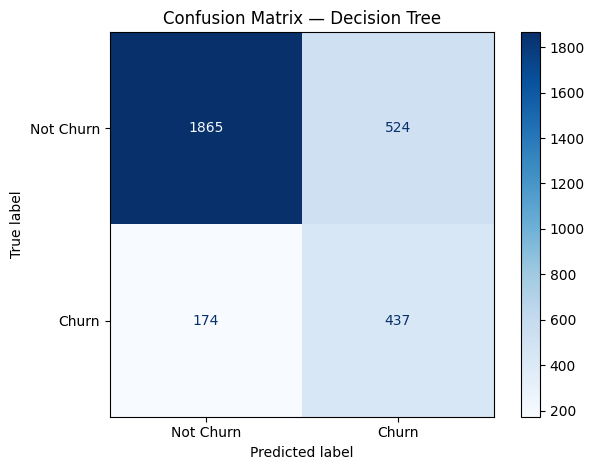

In [13]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Churn", "Churn"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Decision Tree")
plt.grid(False)
plt.tight_layout()
plt.show()

## 13. Per-Class Recall

In [14]:
class0_recall = cm[0, 0] / cm[0].sum()
class1_recall = cm[1, 1] / cm[1].sum()

print(f"Class 0 (Not Churn) Recall: {class0_recall:.2f}")
print(f"Class 1 (Churn) Recall: {class1_recall:.2f}")

Class 0 (Not Churn) Recall: 0.78
Class 1 (Churn) Recall: 0.72


## 14. Overall Metrics

In [15]:
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.2f}')
print(f'Precision : {precision_score(y_test, y_pred):.2f}')
print(f'Recall    : {recall_score(y_test, y_pred):.2f}')
print(f'F1 Score  : {f1_score(y_test, y_pred):.2f}')

Accuracy  : 0.77
Precision : 0.45
Recall    : 0.72
F1 Score  : 0.56


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.78      0.84      2389
           1       0.45      0.72      0.56       611

    accuracy                           0.77      3000
   macro avg       0.68      0.75      0.70      3000
weighted avg       0.82      0.77      0.78      3000



## 15. Predicted Probabilities and Threshold-Independent Metrics

In [17]:
y_prob = best_dt.predict_proba(X_test)[:, 1]
y_prob

array([0.        , 0.18538198, 0.64590783, ..., 0.78262021, 0.65051467,
       0.09856154], shape=(3000,))

In [18]:
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.2f}")
print(f"PR-AUC Score : {pr_auc:.2f}")

ROC-AUC Score: 0.80
PR-AUC Score : 0.59


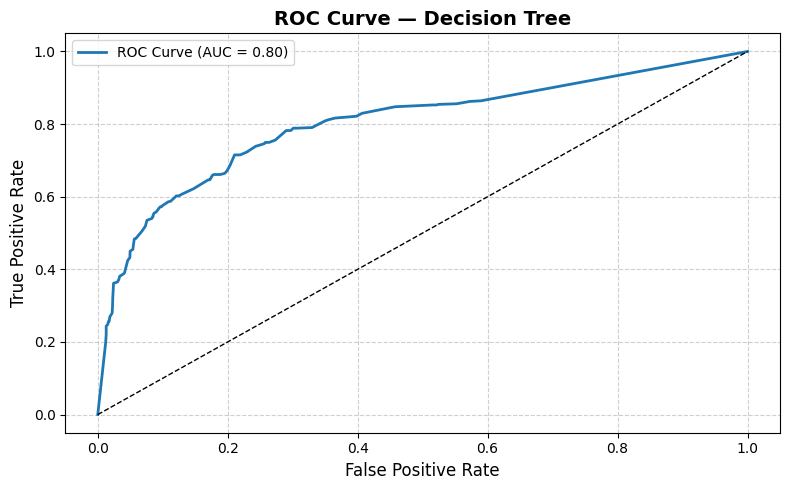

In [19]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — Decision Tree", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

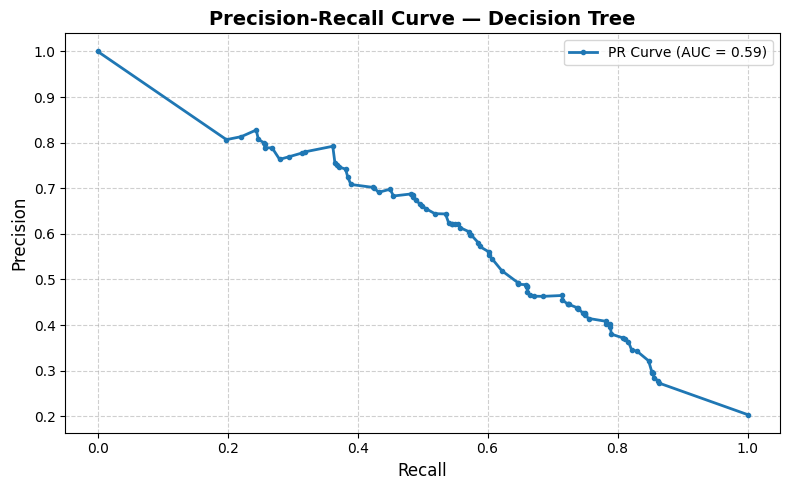

In [20]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, linewidth=2, marker=".", label=f"PR Curve (AUC = {pr_auc:.2f})")
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curve — Decision Tree", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 16. Feature Importance *(added)*

The reference version of this notebook stopped at the curves above. Decision Trees
offer something Logistic Regression's coefficients can't as directly: a built-in
measure of exactly which features drove the most splits — and therefore mattered most
to the model's decisions.

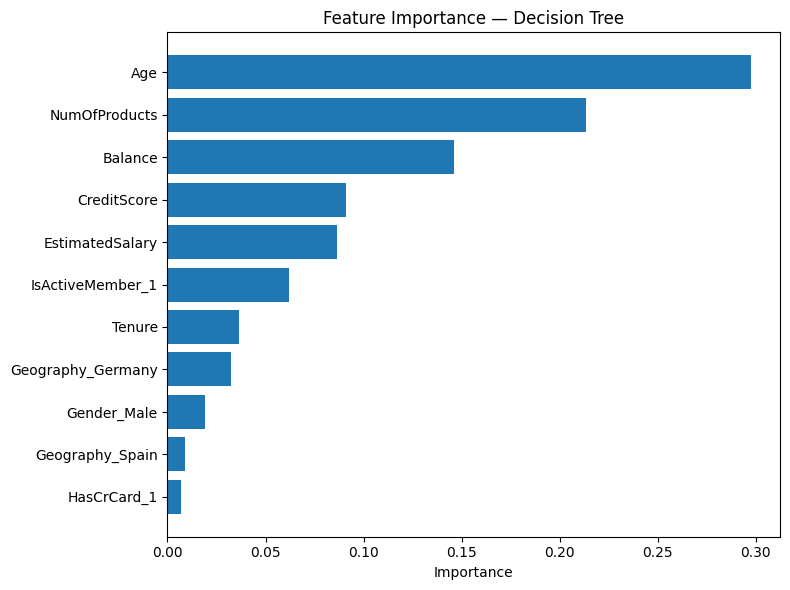

Age                  0.297473
NumOfProducts        0.213225
Balance              0.146141
CreditScore          0.091205
EstimatedSalary      0.086363
IsActiveMember_1     0.061954
Tenure               0.036521
Geography_Germany    0.032435
Gender_Male          0.019248
Geography_Spain      0.008744
HasCrCard_1          0.006692
dtype: float64

In [21]:
ohe_columns = (
    best_dt.named_steps['preprocess']
    .named_transformers_['cat']
    .get_feature_names_out(cat_features)
)
all_feature_names = num_features + list(ohe_columns)

importances = pd.Series(
    best_dt.named_steps['decision_tree'].feature_importances_,
    index=all_feature_names
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(importances.index, importances.values)
plt.xlabel("Importance")
plt.title("Feature Importance — Decision Tree")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

importances

`Age` and `NumOfProducts` dominate the tree's decisions by a wide margin — consistent
with patterns noticed all the way back in the outlier-checking notebook, where older
customers and those with 4 products stood out from the norm.

## 17. Comparison Against the Logistic Regression Series *(added)*

In [22]:
comparison = pd.DataFrame({
    "LogReg Baseline":    [0.81, 0.62, 0.19, 0.29, 0.79, 0.51],
    "LogReg ClassWeight": [0.72, 0.40, 0.73, 0.51, 0.79, 0.50],
    "Decision Tree (Tuned)": [
        round(accuracy_score(y_test, y_pred), 2),
        round(precision_score(y_test, y_pred), 2),
        round(recall_score(y_test, y_pred), 2),
        round(f1_score(y_test, y_pred), 2),
        round(roc_auc, 2),
        round(pr_auc, 2),
    ]
}, index=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"])

comparison

,LogReg Baseline,LogReg ClassWeight,Decision Tree (Tuned)
Accuracy,0.81,0.72,0.77
Precision,0.62,0.40,0.45
Recall,0.19,0.73,0.72
F1 Score,0.29,0.51,0.56
ROC-AUC,0.79,0.79,0.80
PR-AUC,0.51,0.50,0.59


## 18. Summary

- **Recall improved further: ~0.74**, slightly better than any Logistic Regression
  variant (~0.72-0.73).
- **PR-AUC improved meaningfully: ~0.59**, compared to ~0.50-0.51 for every Logistic
  Regression variant. This is the first real evidence in this project that a different
  *model architecture* — not just a different imbalance-handling technique — can push
  past the performance ceiling identified in the classification series.
- **Why this makes sense:** Logistic Regression can only draw a single straight decision
  boundary. A Decision Tree can carve the feature space into many small regions (e.g.
  "older customers AND 1 product AND inactive" vs "younger customers AND 2 products"),
  capturing interactions between features that a linear model cannot represent at all.
- **Best hyperparameters found included `class_weight='balanced'`** — confirming that
  even a non-linear model still benefits from directly addressing class imbalance,
  rather than assuming tree-based models are immune to it.